# PCA, PPCA y Factor Analysis con un ejemplo de cerveza

**Curso:** Estadística Multivariable Aplicada para Ciencia de Datos  
**Duración sugerida:** 60 minutos  
**Tema:** cierre comparativo de PCA, PPCA y Factor Analysis  
**Ejemplo conductor:** perfiles sensoriales de cervezas

## Objetivo general

Comparar **PCA**, **PPCA** y **Factor Analysis** usando un mismo conjunto de datos de cervezas, manteniendo una lectura intuitiva, matemática y aplicada.

La idea central es responder:

> ¿Podemos resumir varios atributos sensoriales de una cerveza en pocas dimensiones latentes interpretables?


## 1. Contexto del ejemplo

Suponga que un grupo de catadores evalúa distintas cervezas artesanales. Para cada cerveza se registran seis atributos sensoriales, todos medidos en escala de 0 a 10:

1. $x_1$: intensidad de lúpulo;
2. $x_2$: amargor;
3. $x_3$: notas cítricas;
4. $x_4$: dulzor de malta;
5. $x_5$: cuerpo;
6. $x_6$: tostado.

Cada fila representa una **unidad de evaluación de cerveza**. Puede ser una cerveza específica, un lote evaluado o el promedio de varias catas de la misma referencia.

Cada columna representa una variable observada.

La pregunta aplicada es:

> ¿Qué dimensiones latentes organizan los perfiles sensoriales de las cervezas?

Una hipótesis razonable es que varias variables responden a dos mundos latentes:

- un eje de perfil **lupulado, amargo y cítrico**;
- un eje de perfil **maltoso, con cuerpo y tostado**.

In [ ]:
# @title Importaciones

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from numpy.linalg import eigh, inv, norm
from sklearn.decomposition import FactorAnalysis

np.set_printoptions(precision=4, suppress=True)
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

## 2. Simulación de datos

Construiremos datos sintéticos pero realistas.

El modelo generador tendrá dos factores latentes reales:

$$
z_1 = \text{perfil lupulado},
$$

$$
z_2 = \text{perfil maltoso}.
$$

Las variables observadas se generan como combinaciones lineales de esos factores más ruido:

$$
x = \mu + Wz + \varepsilon.
$$

Aquí:

- $x \in \mathbb{R}^p$ es una cerveza observada;
- $z \in \mathbb{R}^k$ representa factores latentes;
- $W \in \mathbb{R}^{p \times k}$ es la matriz de cargas;
- $\mu$ es el vector de medias;
- $\varepsilon$ representa ruido de medición o variabilidad específica.

Aunque usamos esta estructura para simular, los modelos se ajustan después como si no conociéramos los factores reales.

In [ ]:
# @title Datos sintéticos: perfiles sensoriales de cervezas

rng = np.random.default_rng(2026)

n = 240
p = 6
k = 2

# Factores latentes reales
# z1: perfil lupulado, amargo y cítrico
# z2: perfil maltoso, con cuerpo y tostado
Z_real = rng.normal(size=(n, k))

# Cargas verdaderas
W_real = np.array([
    [1.50, -0.10],  # intensidad_lupulo
    [1.35, -0.05],  # amargor
    [1.10, -0.20],  # notas_citricas
    [-0.20, 1.30],  # dulzor_malta
    [-0.10, 1.45],  # cuerpo
    [-0.35, 1.20],  # tostado
])

mu_real = np.array([5.4, 5.1, 4.8, 5.0, 5.3, 4.6])

# Ruido específico por variable
# Algunas variables sensoriales pueden ser más variables que otras.
psi_real = np.array([0.35, 0.45, 0.75, 0.40, 0.45, 0.85])
E = rng.normal(scale=np.sqrt(psi_real), size=(n, p))

X = mu_real + Z_real @ W_real.T + E

# Mantener valores en una escala sensorial razonable de 0 a 10.
X = np.clip(X, 0, 10)

columnas = [
    "intensidad_lupulo",
    "amargor",
    "notas_citricas",
    "dulzor_malta",
    "cuerpo",
    "tostado"
]

df = pd.DataFrame(X, columns=columnas)
df.head()

,intensidad_lupulo,amargor,notas_citricas,dulzor_malta,cuerpo,tostado
0,3.344140,4.131204,4.151555,6.016093,4.956409,5.517374
1,2.341729,3.467050,1.791644,6.491730,7.849060,6.149620
2,5.620930,6.586795,5.933259,2.524843,4.194886,3.004580
3,5.282893,5.651502,6.178469,5.903969,5.036529,4.030803
4,4.457454,5.078258,5.646642,3.546955,5.407892,5.278031


In [ ]:
# @title Resumen descriptivo

df.describe().T

,count,mean,std,min,25%,50%,75%,max
intensidad_lupulo,240.0,5.417863,1.636884,0.307905,4.281662,5.321005,6.554413,10.000000
amargor,240.0,5.161012,1.546119,0.413790,4.102294,5.212755,6.155815,9.686104
notas_citricas,240.0,4.895818,1.404457,0.000000,3.924554,4.945145,5.831131,9.060519
dulzor_malta,240.0,4.969621,1.508755,1.413092,3.862880,4.954835,6.085894,9.659765
cuerpo,240.0,5.320374,1.699579,1.057234,4.130468,5.281489,6.492193,10.000000
tostado,240.0,4.495143,1.614687,0.203010,3.319255,4.563702,5.554593,9.532936


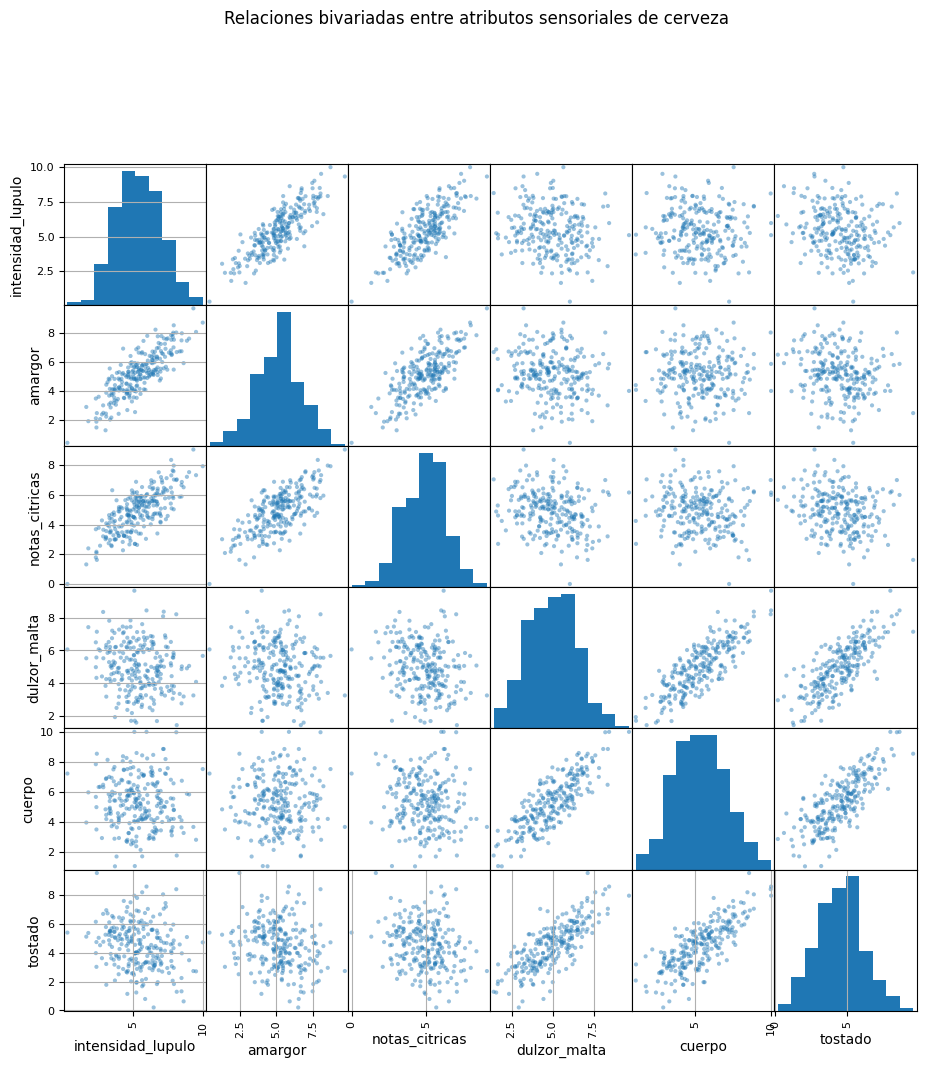

In [ ]:
# @title Visualización inicial de relaciones

pd.plotting.scatter_matrix(df, figsize=(11, 11), diagonal="hist", alpha=0.45)
plt.suptitle("Relaciones bivariadas entre atributos sensoriales de cerveza", y=1.02)
plt.show()

### Lectura inicial

La matriz de dispersión permite ver que varias variables se mueven conjuntamente. Por ejemplo, cervezas con mayor intensidad de lúpulo tienden a tener mayor amargor y más notas cítricas. Por otro lado, cervezas con mayor dulzor de malta tienden a presentar más cuerpo y mayor tostado.

Esto sugiere que las seis variables observadas podrían estar organizadas por pocas dimensiones latentes.

Como todas las variables están en la misma escala sensorial, de 0 a 10, **no estandarizamos**. Solo centramos los datos para trabajar con desviaciones respecto a la media.

## 3. Matriz de datos centrada

Sea

$$
X \in \mathbb{R}^{n \times p}
$$

la matriz de datos originales. Cada fila es una cerveza y cada columna es un atributo sensorial.

Primero calculamos el vector de medias:

$$
\bar x = \frac{1}{n}\sum_{i=1}^{n}x_i.
$$

Luego construimos la matriz centrada:

$$
X_c = X - \mathbf{1}\bar x^T.
$$

En este notebook aplicamos PCA sobre la matriz de covarianzas:

$$
S = \frac{1}{n}X_c^TX_c.
$$

Esto preserva la estructura de variabilidad en la escala original de los atributos sensoriales.

In [ ]:
# @title Datos centrados y matriz de covarianzas

X = df.values
mu = X.mean(axis=0)
X_c = X - mu

S = (X_c.T @ X_c) / n

S_df = pd.DataFrame(S, index=columnas, columns=columnas)
S_df

,intensidad_lupulo,amargor,notas_citricas,dulzor_malta,cuerpo,tostado
intensidad_lupulo,2.668225,2.081631,1.724594,-0.405252,-0.162783,-0.573632
amargor,2.081631,2.380523,1.538967,-0.319633,-0.033869,-0.494769
notas_citricas,1.724594,1.538967,1.964280,-0.440042,-0.225381,-0.470409
dulzor_malta,-0.405252,-0.319633,-0.440042,2.266857,2.090336,1.868043
cuerpo,-0.162783,-0.033869,-0.225381,2.090336,2.876531,2.110933
tostado,-0.573632,-0.494769,-0.470409,1.868043,2.110933,2.596351


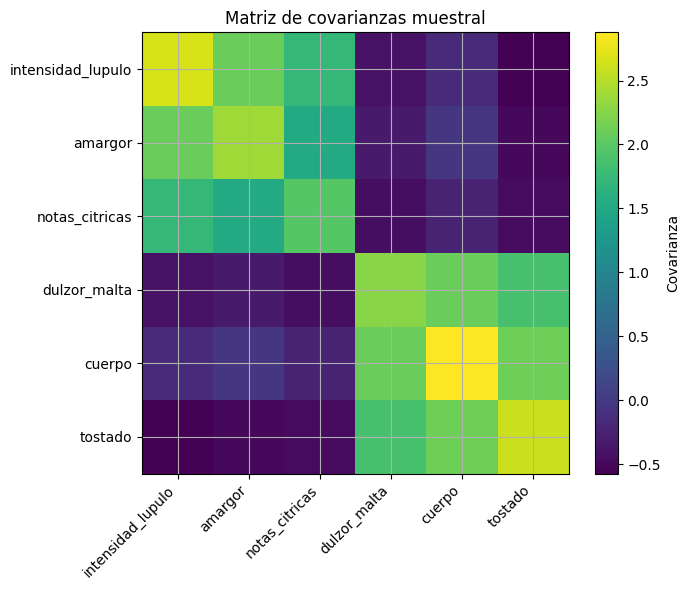

In [ ]:
# @title Mapa de calor de la matriz de covarianzas

plt.figure(figsize=(7, 6))
plt.imshow(S_df, aspect="auto")
plt.colorbar(label="Covarianza")
plt.xticks(range(p), columnas, rotation=45, ha="right")
plt.yticks(range(p), columnas)
plt.title("Matriz de covarianzas muestral")
plt.tight_layout()
plt.show()

La matriz de covarianzas revela dos grupos principales de variables: un perfil lupulado–cítrico y un perfil maltoso–robusto. Las covarianzas negativas entre ambos grupos sugieren que las cervezas más intensas en lúpulo tienden a diferenciarse de las más maltosas y tostadas. Esta estructura será resumida posteriormente mediante PCA, PPCA y Factor Analysis.

## 4. PCA sobre la matriz de covarianzas

PCA busca direcciones ortogonales donde los datos presentan la mayor varianza.

Partimos de la descomposición espectral:

$$
S = Q\Lambda Q^T,
$$

donde:

- $Q=[q_1,\ldots,q_p]$ contiene los autovectores ortonormales;
- $\Lambda=\operatorname{diag}(\lambda_1,\ldots,\lambda_p)$ contiene los autovalores ordenados;
- $\lambda_1 \geq \lambda_2 \geq \cdots \geq \lambda_p$.

Si retenemos las primeras $k$ componentes:

$$
Q_k = [q_1,\ldots,q_k].
$$

Los scores principales son

$$
Z_k = X_c Q_k.
$$

La reconstrucción con $k$ componentes es

$$
\hat X_{PCA} = Z_kQ_k^T + \bar x.
$$

PCA responde principalmente:

> ¿Cuáles son las direcciones de máxima variabilidad en los datos?

In [ ]:
# @title PCA manual sobre covarianzas

eigvals, eigvecs = eigh(S)

# eigh devuelve autovalores en orden ascendente; los ordenamos descendente.
idx = np.argsort(eigvals)[::-1]
eigvals = eigvals[idx]
Q = eigvecs[:, idx]

var_exp = eigvals / eigvals.sum()
var_acum = np.cumsum(var_exp)

pca_resumen = pd.DataFrame({
    "componente": [f"PC{i+1}" for i in range(p)],
    "autovalor": eigvals,
    "varianza_explicada": var_exp,
    "varianza_acumulada": var_acum
})

pca_resumen

,componente,autovalor,varianza_explicada,varianza_acumulada
0,PC1,7.386866,0.500711,0.500711
1,PC2,5.265955,0.356947,0.857657
2,PC3,0.698474,0.047345,0.905003
3,PC4,0.539495,0.036569,0.941572
4,PC5,0.458028,0.031047,0.972619
5,PC6,0.403950,0.027381,1.000000


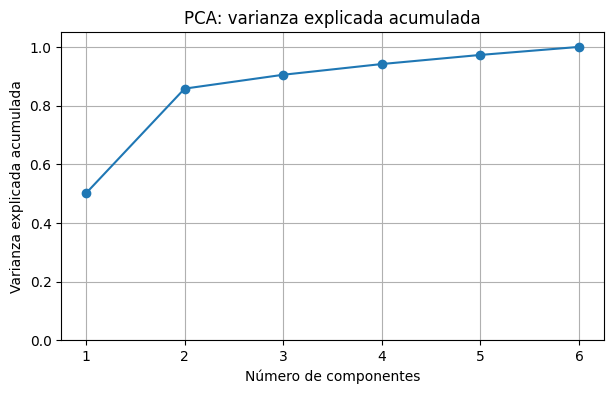

In [ ]:
# @title Varianza explicada por PCA

plt.figure(figsize=(7, 4))
plt.plot(range(1, p + 1), var_acum, marker="o")
plt.xticks(range(1, p + 1))
plt.ylim(0, 1.05)
plt.xlabel("Número de componentes")
plt.ylabel("Varianza explicada acumulada")
plt.title("PCA: varianza explicada acumulada")
plt.show()

In [ ]:
# @title Cargas de las dos primeras componentes

Q_k = Q[:, :k]
Z_pca = X_c @ Q_k

cargas_pca = pd.DataFrame(
    Q_k,
    index=columnas,
    columns=["PC1", "PC2"]
)

cargas_pca

,PC1,PC2
intensidad_lupulo,-0.372991,-0.510789
amargor,-0.330412,-0.487591
notas_citricas,-0.310366,-0.384954
dulzor_malta,0.445703,-0.297773
cuerpo,0.466756,-0.430731
tostado,0.488740,-0.281002


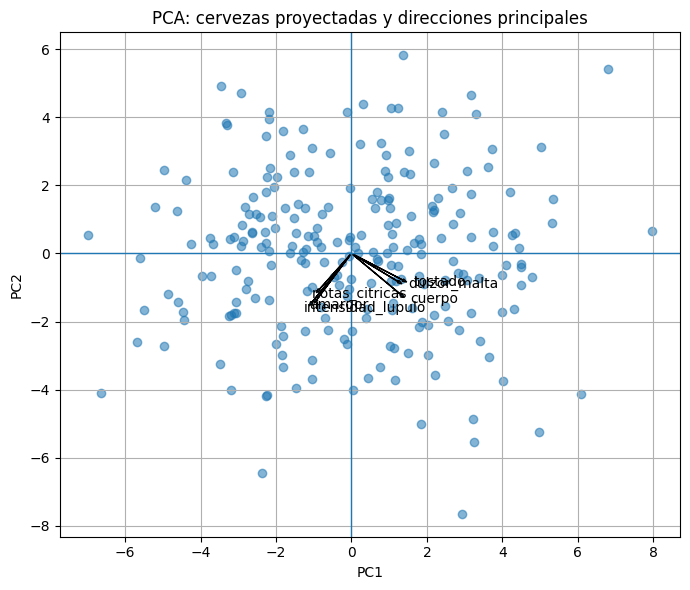

In [ ]:
# @title Biplot sencillo de PCA

plt.figure(figsize=(7, 6))
plt.scatter(Z_pca[:, 0], Z_pca[:, 1], alpha=0.55)
plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)

escala = 3.0
for j, var in enumerate(columnas):
    plt.arrow(0, 0, escala * Q_k[j, 0], escala * Q_k[j, 1],
              head_width=0.08, length_includes_head=True)
    plt.text(escala * Q_k[j, 0] * 1.12, escala * Q_k[j, 1] * 1.12, var)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA: cervezas proyectadas y direcciones principales")
plt.tight_layout()
plt.show()

### Interpretación de PCA

En este ejemplo, las dos primeras componentes deberían capturar buena parte de la variabilidad sensorial.

Una lectura esperada es:

- **PC1** puede separar cervezas de perfil lupulado, amargo y cítrico frente a cervezas más maltosas.
- **PC2** puede capturar variación adicional asociada con cuerpo, tostado o combinaciones secundarias.

PCA es muy útil para visualizar, reducir dimensión y reconstruir datos con pocas componentes. Sin embargo, PCA no plantea explícitamente un modelo generativo ni separa ruido común y ruido específico.

## 5. PPCA: versión probabilística de PCA

PPCA introduce una interpretación probabilística mediante el modelo

$$
x = \mu + Wz + \varepsilon,
$$

con

$$
z \sim N(0,I_k),
$$

y

$$
\varepsilon \sim N(0,\sigma^2 I_p).
$$

Entonces la distribución marginal de $x$ es

$$
x \sim N(\mu,C),
$$

donde

$$
C = WW^T+\sigma^2 I_p.
$$

La matriz $WW^T$ representa la estructura latente común de baja dimensión. El término $\sigma^2 I_p$ representa ruido isotrópico, es decir, el mismo ruido para todas las variables observadas.

Usando la solución cerrada de PPCA, si

$$
S = Q\Lambda Q^T,
$$

entonces

$$
\hat\sigma^2 = \frac{1}{p-k}\sum_{j=k+1}^{p}\lambda_j.
$$

Una elección conveniente para la matriz de cargas es

$$
\hat W = Q_k(\Lambda_k-\hat\sigma^2 I_k)^{1/2}.
$$

PPCA responde principalmente:

> ¿Qué factores latentes podrían generar los datos bajo un ruido común para todas las variables?

In [ ]:
# @title Estimación cerrada de PPCA

lambda_k = eigvals[:k]
Q_k = Q[:, :k]

sigma2_hat = eigvals[k:].mean()

W_ppca = Q_k @ np.diag(np.sqrt(np.maximum(lambda_k - sigma2_hat, 0)))

C_ppca = W_ppca @ W_ppca.T + sigma2_hat * np.eye(p)

M = W_ppca.T @ W_ppca + sigma2_hat * np.eye(k)
Z_ppca = X_c @ W_ppca @ inv(M)

Xhat_ppca = Z_ppca @ W_ppca.T + mu

pd.DataFrame(W_ppca, index=columnas, columns=["Factor_1", "Factor_2"])

,Factor_1,Factor_2
intensidad_lupulo,-0.977056,-1.112181
amargor,-0.865520,-1.061668
notas_citricas,-0.813008,-0.838190
dulzor_malta,1.167528,-0.648365
cuerpo,1.222676,-0.937864
tostado,1.280265,-0.611846


In [ ]:
# @title Ruido común estimado en PPCA

print(f"sigma2_hat = {sigma2_hat:.4f}")

sigma2_hat = 0.5250


In [ ]:
# @title Matriz de covarianza estimada por PPCA

pd.DataFrame(C_ppca, index=columnas, columns=columnas)

,intensidad_lupulo,amargor,notas_citricas,dulzor_malta,cuerpo,tostado
intensidad_lupulo,2.716570,2.026428,1.726573,-0.419641,-0.151548,-0.570407
amargor,2.026428,2.401250,1.593554,-0.322170,-0.062550,-0.458517
notas_citricas,1.726573,1.593554,1.888531,-0.405757,-0.207938,-0.528023
dulzor_malta,-0.419641,-0.322170,-0.405757,2.308485,2.035586,1.891444
cuerpo,-0.151548,-0.062550,-0.207938,2.035586,2.899511,2.139177
tostado,-0.570407,-0.458517,-0.528023,1.891444,2.139177,2.538420


### Interpretación de PPCA

PPCA conserva una relación estrecha con PCA, pero cambia la pregunta.

PCA pregunta por direcciones de máxima varianza. PPCA pregunta por un mecanismo probabilístico capaz de generar observaciones parecidas a las observadas.

La restricción clave es:

$$
\operatorname{Var}(\varepsilon_j)=\sigma^2,
\qquad
j=1,\ldots,p.
$$

En el contexto de cerveza, esto significa asumir que el ruido específico de amargor, cuerpo, tostado, notas cítricas, dulzor de malta e intensidad de lúpulo tiene la misma magnitud. Ese supuesto puede ser demasiado fuerte si algunas variables son más subjetivas o difíciles de evaluar.

In [ ]:
# ============================================================
# Comparación entre la covarianza observada y la covarianza PPCA
# ============================================================

# Covarianza observada
S_df = pd.DataFrame(S, index=columnas, columns=columnas)

# Covarianza reconstruida por PPCA
Cppca_df = pd.DataFrame(C_ppca, index=columnas, columns=columnas)

print("Covarianza observada S")
display(S_df.round(3))

print("\nCovarianza reconstruida por PPCA")
display(Cppca_df.round(3))

# Diferencia entre ambas
diff_df = S_df - Cppca_df

print("\nDiferencia: S - C_ppca")
display(diff_df.round(3))

Covarianza observada S


,intensidad_lupulo,amargor,notas_citricas,dulzor_malta,cuerpo,tostado
intensidad_lupulo,2.668,2.082,1.725,-0.405,-0.163,-0.574
amargor,2.082,2.381,1.539,-0.320,-0.034,-0.495
notas_citricas,1.725,1.539,1.964,-0.440,-0.225,-0.470
dulzor_malta,-0.405,-0.320,-0.440,2.267,2.090,1.868
cuerpo,-0.163,-0.034,-0.225,2.090,2.877,2.111
tostado,-0.574,-0.495,-0.470,1.868,2.111,2.596



Covarianza reconstruida por PPCA


,intensidad_lupulo,amargor,notas_citricas,dulzor_malta,cuerpo,tostado
intensidad_lupulo,2.717,2.026,1.727,-0.420,-0.152,-0.570
amargor,2.026,2.401,1.594,-0.322,-0.063,-0.459
notas_citricas,1.727,1.594,1.889,-0.406,-0.208,-0.528
dulzor_malta,-0.420,-0.322,-0.406,2.308,2.036,1.891
cuerpo,-0.152,-0.063,-0.208,2.036,2.900,2.139
tostado,-0.570,-0.459,-0.528,1.891,2.139,2.538



Diferencia: S - C_ppca


,intensidad_lupulo,amargor,notas_citricas,dulzor_malta,cuerpo,tostado
intensidad_lupulo,-0.048,0.055,-0.002,0.014,-0.011,-0.003
amargor,0.055,-0.021,-0.055,0.003,0.029,-0.036
notas_citricas,-0.002,-0.055,0.076,-0.034,-0.017,0.058
dulzor_malta,0.014,0.003,-0.034,-0.042,0.055,-0.023
cuerpo,-0.011,0.029,-0.017,0.055,-0.023,-0.028
tostado,-0.003,-0.036,0.058,-0.023,-0.028,0.058


## 6. Factor Analysis

Factor Analysis conserva el modelo latente

$$
x = \mu + Wz + \varepsilon,
$$

con

$$
z \sim N(0,I_k),
$$

pero reemplaza el ruido común de PPCA por ruido específico por variable:

$$
\varepsilon \sim N(0,\Psi),
$$

donde

$$
\Psi=\operatorname{diag}(\psi_1,\psi_2,\ldots,\psi_p).
$$

La distribución marginal es

$$
x \sim N(\mu,WW^T+\Psi).
$$

Por tanto,

$$
C_{FA}=WW^T+\Psi.
$$

Factor Analysis responde principalmente:

> ¿Qué factores comunes explican la dependencia entre variables y qué parte queda como variación específica de cada atributo?

In [ ]:
# @title Ajuste de Factor Analysis

fa = FactorAnalysis(n_components=k, random_state=2026)
Z_fa = fa.fit_transform(X)

W_fa = fa.components_.T
psi_hat = fa.noise_variance_
mu_fa = fa.mean_

C_fa = W_fa @ W_fa.T + np.diag(psi_hat)
Xhat_fa = Z_fa @ fa.components_ + mu_fa

cargas_fa = pd.DataFrame(W_fa, index=columnas, columns=["Factor_1", "Factor_2"])
cargas_fa

,Factor_1,Factor_2
intensidad_lupulo,-1.087289,1.054523
amargor,-0.952221,0.992577
notas_citricas,-0.861864,0.736177
dulzor_malta,1.122076,0.758059
cuerpo,1.154614,1.050157
tostado,1.199098,0.689312


In [ ]:
# @title Unicidades estimadas

unicidades = pd.DataFrame({
    "variable": columnas,
    "psi_j": psi_hat
})

unicidades

,variable,psi_j
0,intensidad_lupulo,0.376263
1,amargor,0.487021
2,notas_citricas,0.679277
3,dulzor_malta,0.432603
4,cuerpo,0.441608
5,tostado,0.683070


Los valores $\psi_j$ representan la varianza específica o unicidad de cada variable en Factor Analysis. Valores altos indican que una parte importante de la variabilidad de la variable no es explicada por los factores comunes. En este caso, notas_citricas y tostado presentan las mayores unicidades, sugiriendo que contienen comportamiento más individual o menos compartido con la estructura latente común.

## 7. Comunalidad y unicidad

En Factor Analysis, la varianza de cada variable se descompone como

$$
\operatorname{Var}(x_j)=h_j^2+\psi_j.
$$

Aquí:

- $h_j^2$ es la **comunalidad**;
- $\psi_j$ es la **unicidad** o varianza específica.

La comunalidad se calcula como la suma de cuadrados de las cargas de la variable $j$:

$$
h_j^2=\sum_{\ell=1}^{k}w_{j\ell}^2.
$$

A diferencia del caso estandarizado, aquí no esperamos que

$$
h_j^2+\psi_j=1.
$$

Como estamos trabajando en escala original, esperamos que

$$
h_j^2+\psi_j \approx S_{jj}.
$$

Es decir, la suma debe aproximar la varianza muestral de la variable $j$.

In [ ]:
# @title Comunalidades, unicidades y varianzas observadas

h2 = np.sum(W_fa**2, axis=1)
var_observada = np.diag(S)

tabla_fa = pd.DataFrame({
    "variable": columnas,
    "varianza_observada_Sjj": var_observada,
    "comunalidad_h2": h2,
    "unicidad_psi": psi_hat,
    "h2_mas_psi": h2 + psi_hat
})

tabla_fa

,variable,varianza_observada_Sjj,comunalidad_h2,unicidad_psi,h2_mas_psi
0,intensidad_lupulo,2.668225,2.294217,0.376263,2.670481
1,amargor,2.380523,1.891933,0.487021,2.378954
2,notas_citricas,1.964280,1.284765,0.679277,1.964042
3,dulzor_malta,2.266857,1.833709,0.432603,2.266312
4,cuerpo,2.876531,2.435964,0.441608,2.877572
5,tostado,2.596351,1.912988,0.683070,2.596059


La descomposición muestra que la varianza observada de cada variable se separa en dos partes: comunalidad $h_j^2$, explicada por los factores comunes, y unicidad $\psi_j$, asociada a comportamiento específico o ruido. Variables como intensidad_lupulo y cuerpo presentan altas comunalidades, por lo que están bien representadas por la estructura latente común, mientras que notas_citricas y tostado conservan una mayor proporción de variabilidad específica.

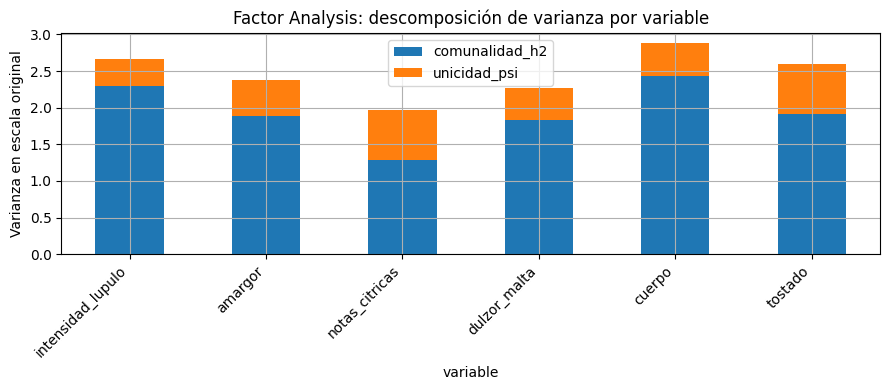

In [ ]:
# @title Visualización de comunalidad y unicidad

tabla_plot = tabla_fa.set_index("variable")[["comunalidad_h2", "unicidad_psi"]]

tabla_plot.plot(kind="bar", stacked=True, figsize=(9, 4))
plt.ylabel("Varianza en escala original")
plt.title("Factor Analysis: descomposición de varianza por variable")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

La gráfica muestra cómo Factor Analysis descompone la varianza total de cada variable en una parte común, explicada por los factores latentes ($h_j^2$), y una parte específica o residual ($\psi_j$). Variables como intensidad_lupulo y cuerpo están fuertemente explicadas por la estructura común, mientras que notas_citricas y tostado conservan una proporción relativamente mayor de variabilidad propia no compartida con los demás atributos.

### Interpretación de Factor Analysis

Factor Analysis permite identificar qué atributos están bien representados por los factores comunes y cuáles conservan más variación específica.

En el ejemplo de cerveza:

- si `intensidad_lupulo`, `amargor` y `notas_citricas` tienen alta comunalidad, están fuertemente asociados con el perfil lupulado;
- si `dulzor_malta`, `cuerpo` y `tostado` tienen alta comunalidad, están asociados con el perfil maltoso;
- si una variable tiene alta unicidad, contiene variabilidad propia no explicada por los factores comunes.

Esta es una diferencia importante frente a PCA y PPCA.

## 8. Comparación de matrices de covarianza

La matriz muestral es

$$
S = \frac{1}{n}X_c^TX_c.
$$

PPCA aproxima $S$ mediante

$$
\hat C_{PPCA}=\hat W\hat W^T+\hat\sigma^2 I_p.
$$

Factor Analysis aproxima $S$ mediante

$$
\hat C_{FA}=\hat W\hat W^T+\hat\Psi.
$$

Para comparar qué tan bien cada modelo reproduce la estructura de covarianzas observada, comparamos la matriz original $S$ con la matriz reconstruida $\hat C$ mediante la norma de Frobenius:

$$
\|S-\hat C\|_F
=
\left(
\sum_{i=1}^{p}\sum_{j=1}^{p}
(S_{ij}-\hat C_{ij})^2
\right)^{1/2}.
$$

Esta métrica resume el tamaño total de las diferencias entre ambas matrices. Valores pequeños indican que el modelo logra reconstruir adecuadamente la estructura de varianzas y covarianzas de los datos originales.

In [ ]:
# @title Errores de reconstrucción de covarianza

err_cov_ppca = norm(S - C_ppca, ord="fro")
err_cov_fa = norm(S - C_fa, ord="fro")

errores_cov = pd.DataFrame({
    "modelo": ["PPCA", "Factor Analysis"],
    "error_frobenius_covarianza": [err_cov_ppca, err_cov_fa]
})

errores_cov

,modelo,error_frobenius_covarianza
0,PPCA,0.222355
1,Factor Analysis,0.116242


El error de Frobenius muestra que ambos modelos reconstruyen bien la matriz de covarianzas observada, pero Factor Analysis obtiene un error menor que PPCA. Esto sugiere que, en este ejemplo, permitir unicidades específicas por variable mediante $\Psi$ mejora la aproximación frente al supuesto más restrictivo de ruido isotrópico en PPCA.

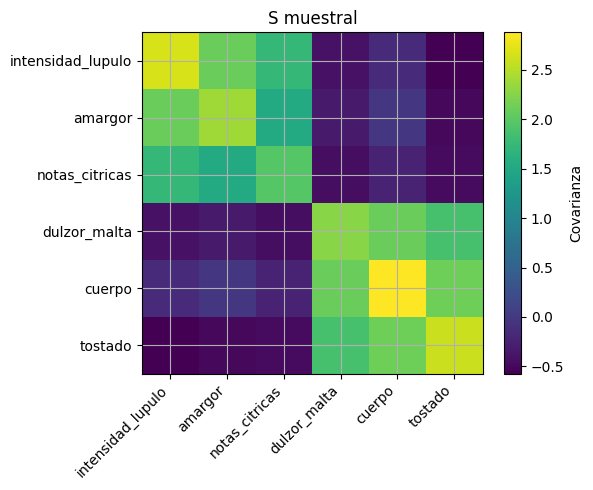

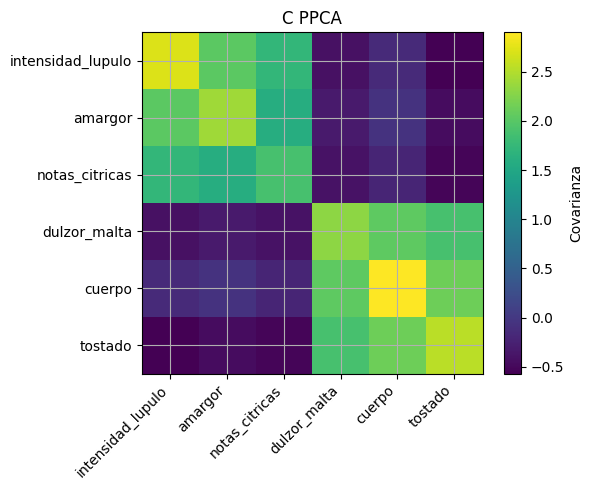

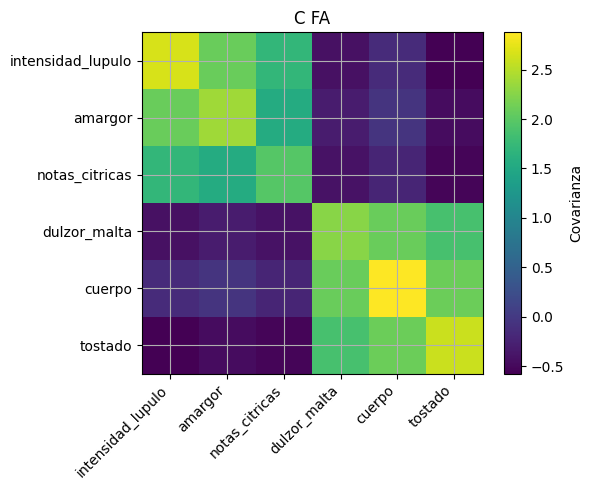

In [ ]:
# @title Comparación visual de matrices de covarianza

matrices = {
    "S muestral": S,
    "C PPCA": C_ppca,
    "C FA": C_fa
}

for titulo, M_cov in matrices.items():
    plt.figure(figsize=(6, 5))
    plt.imshow(M_cov, aspect="auto")
    plt.colorbar(label="Covarianza")
    plt.xticks(range(p), columnas, rotation=45, ha="right")
    plt.yticks(range(p), columnas)
    plt.title(titulo)
    plt.tight_layout()
    plt.show()

## 9. Comparación de reconstrucción de datos

Aunque PCA, PPCA y Factor Analysis están relacionados, no reconstruyen los datos desde la misma lógica.

En PCA:

$$
\hat X_{PCA}=Z_kQ_k^T+\bar x.
$$

En PPCA:

$$
\hat X_{PPCA}=\hat Z\hat W^T+\hat\mu.
$$

En Factor Analysis:

$$
\hat X_{FA}=\hat Z\hat W^T+\hat\mu.
$$

Usaremos el MSE:

$$
MSE=\frac{1}{np}\sum_{i=1}^{n}\sum_{j=1}^{p}(x_{ij}-\hat x_{ij})^2.
$$

Un menor MSE indica mejor reconstrucción directa de los datos.

In [ ]:
# @title Reconstrucción y MSE

Xhat_pca = Z_pca @ Q_k.T + mu

mse_pca = np.mean((X - Xhat_pca)**2)
mse_ppca = np.mean((X - Xhat_ppca)**2)
mse_fa = np.mean((X - Xhat_fa)**2)

mse_tabla = pd.DataFrame({
    "modelo": ["PCA", "PPCA", "Factor Analysis"],
    "mse_reconstruccion": [mse_pca, mse_ppca, mse_fa]
})

mse_tabla

,modelo,mse_reconstruccion
0,PCA,0.349991
1,PPCA,0.364933
2,Factor Analysis,0.370261


Los tres modelos logran reconstrucciones similares de los datos originales, aunque PCA obtiene el menor MSE. Esto es esperable porque PCA está diseñado específicamente para minimizar el error cuadrático de reconstrucción. PPCA y Factor Analysis sacrifican ligeramente precisión de reconstrucción a cambio de incorporar una interpretación probabilística y una estructura explícita de ruido y variabilidad específica.

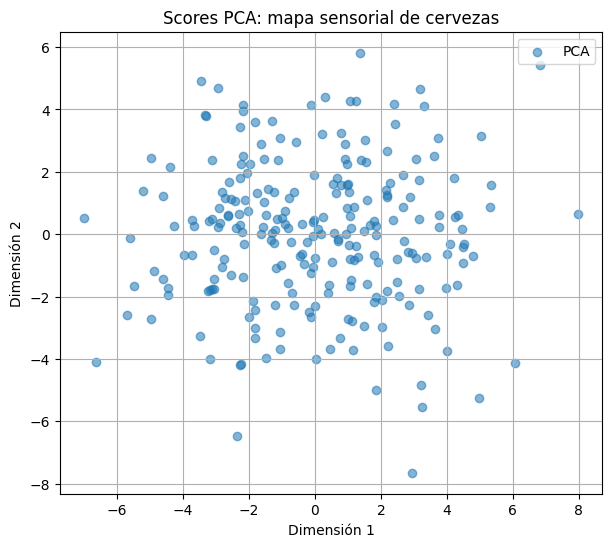

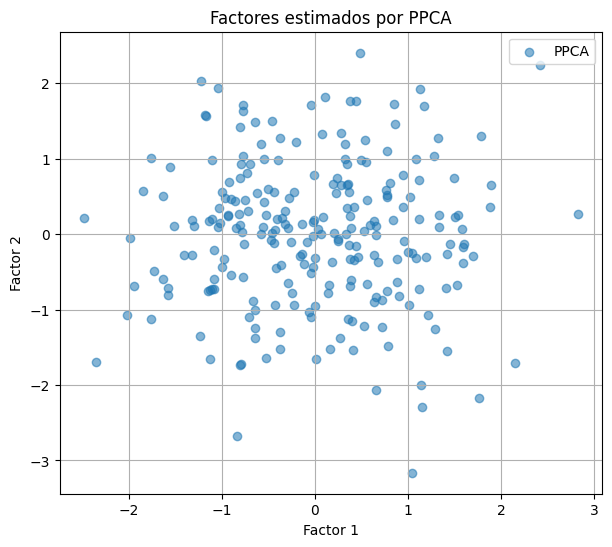

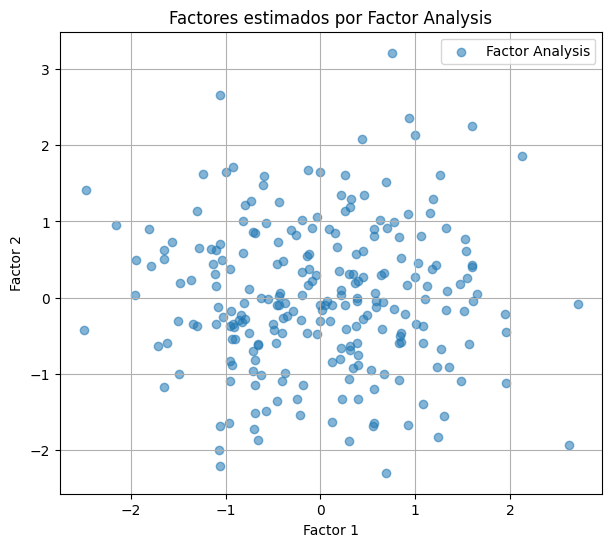

In [ ]:
# @title Visualización de scores latentes

plt.figure(figsize=(7, 6))
plt.scatter(Z_pca[:, 0], Z_pca[:, 1], alpha=0.55, label="PCA")
plt.xlabel("Dimensión 1")
plt.ylabel("Dimensión 2")
plt.title("Scores PCA: mapa sensorial de cervezas")
plt.legend()
plt.show()

plt.figure(figsize=(7, 6))
plt.scatter(Z_ppca[:, 0], Z_ppca[:, 1], alpha=0.55, label="PPCA")
plt.xlabel("Factor 1")
plt.ylabel("Factor 2")
plt.title("Factores estimados por PPCA")
plt.legend()
plt.show()

plt.figure(figsize=(7, 6))
plt.scatter(Z_fa[:, 0], Z_fa[:, 1], alpha=0.55, label="Factor Analysis")
plt.xlabel("Factor 1")
plt.ylabel("Factor 2")
plt.title("Factores estimados por Factor Analysis")
plt.legend()
plt.show()

## 10. Comparación conceptual final

| Modelo | Pregunta central | Supuesto clave | Ventaja principal | Limitación principal |
|---|---|---|---|---|
| PCA | ¿Dónde está la mayor varianza? | Componentes ortogonales | Simple, geométrico, excelente para reducción de dimensión | No separa estructura común y ruido |
| PPCA | ¿Qué factores latentes generan los datos con ruido común? | $\varepsilon \sim N(0,\sigma^2 I_p)$ | Probabilístico y generativo | Mismo ruido para todas las variables |
| Factor Analysis | ¿Qué factores comunes explican la dependencia entre variables? | $\varepsilon \sim N(0,\Psi)$ | Permite ruido específico por variable | Estimación más exigente e interpretación sensible a rotaciones |

La diferencia central puede resumirse así:

$$
\text{PCA: varianza máxima},
$$

$$
\text{PPCA: factores latentes con ruido común},
$$

$$
\text{FA: factores comunes con ruido específico por variable}.
$$

## 11. Conclusión aplicada

En el ejemplo de cervezas, PCA permite construir un mapa sensorial de baja dimensión. Esto es útil para visualizar estilos, encontrar grupos de cervezas y resumir perfiles.

PPCA agrega una interpretación probabilística: las cervezas observadas pueden pensarse como generadas por pocos factores latentes más ruido común.

Factor Analysis ofrece la lectura más fina cuando interesa separar variabilidad común y variabilidad específica. En particular, permite decir qué atributos sensoriales están fuertemente conectados con los factores latentes y cuáles tienen más variación propia.

En una sesión de cierre, las preguntas que cada modelo ayuda a responder son:

1. **PCA:** ¿cómo resumimos la variabilidad sensorial en pocas dimensiones?
2. **PPCA:** ¿qué estructura latente probabilística podría generar estos perfiles?
3. **Factor Analysis:** ¿qué atributos comparten factores comunes y cuáles tienen variación específica relevante?

Para este problema, una conclusión razonable es:

> PCA es el mejor punto de entrada visual y geométrico; PPCA es el puente probabilístico; Factor Analysis es el modelo más interpretativo cuando el objetivo es hablar de factores comunes y ruido específico por atributo.

## 12. Cierre para discusión en clase

Use las salidas anteriores para responder oralmente:

1. ¿Qué representa una fila y qué representa una columna?
2. ¿Por qué aquí no estandarizamos los datos?
3. ¿Qué representa PC1?
4. ¿Qué representa PC2?
5. ¿Qué gana PPCA frente a PCA?
6. ¿Qué significa $\hat\sigma^2$ en PPCA?
7. ¿Qué gana Factor Analysis frente a PPCA?
8. ¿Qué variable tiene mayor unicidad?
9. ¿Cuál modelo recomendaría si el interés es visualización?
10. ¿Cuál modelo recomendaría si el interés es interpretación latente?